In [41]:
import io
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving SB11_20231.TXT to SB11_20231.TXT


In [10]:
datos_icfes = pd.read_csv(io.BytesIO(uploaded['SB11_20231.TXT']),
 delimiter='¬')
datos_icfes.head()

/tmp/ipykernel_9207/2411619489.py:1: ParserWarning: Falling back to the 'python' engine because the separator encoded in utf-8 is > 1 char long, and the 'c' engine does not support such separators; you can avoid this warning by specifying engine='python'.
  datos_icfes = pd.read_csv(io.BytesIO(uploaded['SB11_20231.TXT']),


,ESTU_TIPODOCUMENTO,ESTU_NACIONALIDAD,ESTU_GENERO,ESTU_FECHANACIMIENTO,PERIODO,ESTU_CONSECUTIVO,ESTU_ESTUDIANTE,ESTU_PAIS_RESIDE,ESTU_DEPTO_RESIDE,ESTU_COD_RESIDE_DEPTO,...,PUNT_INGLES,PERCENTIL_INGLES,DESEMP_INGLES,PUNT_GLOBAL,PERCENTIL_GLOBAL,ESTU_INSE_INDIVIDUAL,ESTU_NSE_INDIVIDUAL,ESTU_NSE_ESTABLECIMIENTO,PERCENTIL_ESPECIAL_GLOBAL,ESTU_ESTADOINVESTIGACION
0,TI,COLOMBIA,F,04/11/2005,20231,SB11202310019049,ESTUDIANTE,COLOMBIA,CUNDINAMARCA,25,...,87.0,94.0,B+,422,100.0,67.532814,4.0,4,100.0,PUBLICAR
1,TI,COLOMBIA,M,08/04/2007,20231,SB11202310017318,ESTUDIANTE,COLOMBIA,VALLE,76,...,NaN,NaN,NaN,326,NaN,47.223972,2.0,3,100.0,PUBLICAR
2,TI,COLOMBIA,F,26/05/2006,20231,SB11202310030916,ESTUDIANTE,COLOMBIA,VALLE,76,...,NaN,NaN,NaN,186,NaN,67.695519,4.0,3,40.0,PUBLICAR
3,CC,COLOMBIA,F,24/05/2004,20231,SB11202310074169,ESTUDIANTE,COLOMBIA,VALLE,76,...,58.0,43.0,A2,200,12.0,41.863163,2.0,3,58.0,PUBLICAR
4,TI,COLOMBIA,F,04/05/2005,20231,SB11202310044933,ESTUDIANTE,COLOMBIA,VALLE,76,...,69.0,57.0,B1,263,39.0,51.223795,3.0,3,92.0,PUBLICAR


#Eliminación de valores faltantes

In [11]:
icfes_sin_nan = datos_icfes[(~datos_icfes['ESTU_INSE_INDIVIDUAL'].isna()) &
 (~datos_icfes['PUNT_LECTURA_CRITICA'].isna()) &
 (~datos_icfes['PUNT_MATEMATICAS'].isna()) &
 (~datos_icfes['PUNT_C_NATURALES'].isna()) &
 (~datos_icfes['PUNT_SOCIALES_CIUDADANAS'].isna()) &
 (~datos_icfes['PUNT_INGLES'].isna())]

icfes_sin_nan.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11853 entries, 0 to 12703
Data columns (total 83 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   ESTU_TIPODOCUMENTO             11853 non-null  object 
 1   ESTU_NACIONALIDAD              11853 non-null  object 
 2   ESTU_GENERO                    11853 non-null  object 
 3   ESTU_FECHANACIMIENTO           11853 non-null  object 
 4   PERIODO                        11853 non-null  int64  
 5   ESTU_CONSECUTIVO               11853 non-null  object 
 6   ESTU_ESTUDIANTE                11853 non-null  object 
 7   ESTU_PAIS_RESIDE               11853 non-null  object 
 8   ESTU_DEPTO_RESIDE              11853 non-null  object 
 9   ESTU_COD_RESIDE_DEPTO          11853 non-null  int64  
 10  ESTU_MCPIO_RESIDE              11853 non-null  object 
 11  ESTU_COD_RESIDE_MCPIO          11853 non-null  int64  
 12  ESTU_PRESENTACIONSABADO        11851 non-null  obje

Se eliminaron las observaciones con valores faltantes en las variables analizadas

In [12]:
tabla_regresion = datos_icfes[['ESTU_INSE_INDIVIDUAL','PUNT_LECTURA_CRITICA','PUNT_MATEMATICAS','PUNT_C_NATURALES',
                               'PUNT_SOCIALES_CIUDADANAS','PUNT_INGLES']]
tabla_regresion.head(4)

,ESTU_INSE_INDIVIDUAL,PUNT_LECTURA_CRITICA,PUNT_MATEMATICAS,PUNT_C_NATURALES,PUNT_SOCIALES_CIUDADANAS,PUNT_INGLES
0,67.532814,100,83,77,77,87.0
1,47.223972,67,58,68,68,NaN
2,67.695519,37,42,35,35,NaN
3,41.863163,45,41,41,27,58.0


In [17]:
tabla_regresion1 = datos_icfes[['ESTU_INSE_INDIVIDUAL',
                               'PUNT_LECTURA_CRITICA',
                               'PUNT_MATEMATICAS',
                               'PUNT_C_NATURALES',
                               'PUNT_SOCIALES_CIUDADANAS',
                               'PUNT_INGLES']].dropna()

#Selección de variables explicativas a partir de los diagramas de dispersión

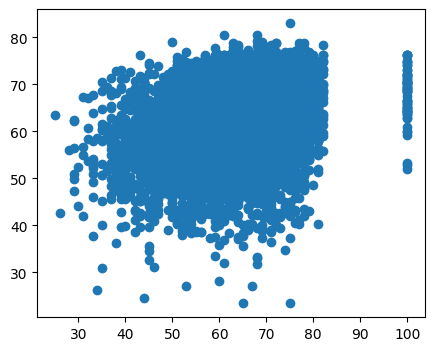

In [18]:
plt.figure(figsize=(5,4))
plt.scatter(tabla_regresion["PUNT_LECTURA_CRITICA"], tabla_regresion["ESTU_INSE_INDIVIDUAL"])
plt.show()

Se observa una relación positiva débil entre el puntaje de lectura crítica y el nivel socioeconómico. Los datos presentan alta dispersión, por lo que no es una variable fuertemente explicativa

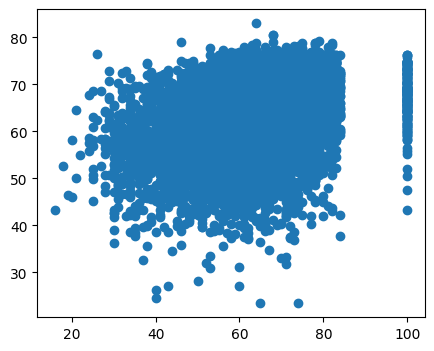

In [19]:
plt.figure(figsize=(5,4))
plt.scatter(tabla_regresion1["PUNT_MATEMATICAS"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])
plt.show()

Se observa una relación positiva moderada entre el puntaje de matemáticas y el nivel socioeconómico. Sin embargo, la dispersión indica que su capacidad explicativa es limitada

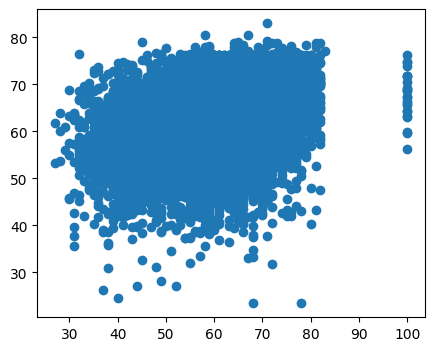

In [20]:
plt.figure(figsize=(5,4))
plt.scatter(tabla_regresion1["PUNT_C_NATURALES"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])
plt.show()

Se evidencia una relación positiva débil, con alta dispersión de los datos, lo que indica una baja capacidad explicativa respecto al nivel socioeconómico

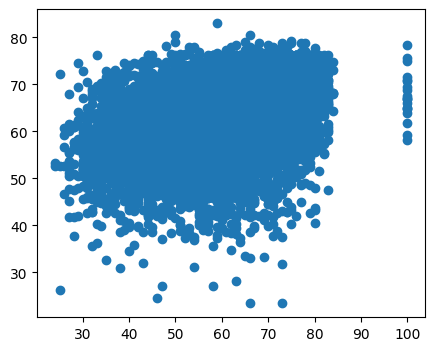

In [21]:
plt.figure(figsize=(5,4))
plt.scatter(tabla_regresion1["PUNT_SOCIALES_CIUDADANAS"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])
plt.show()

La relación entre el puntaje de sociales y el nivel socioeconómico es positiva pero débil, con una distribución dispersa que sugiere poca influencia en el modelo

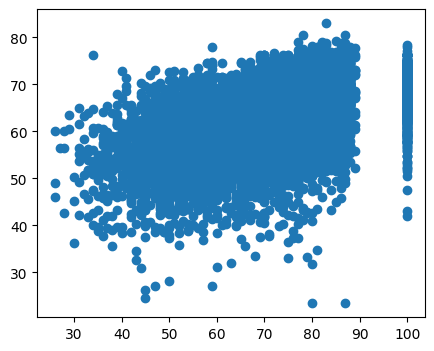

In [22]:
plt.figure(figsize=(5,4))
plt.scatter(tabla_regresion1["PUNT_INGLES"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])
plt.show()

Se observa una relación positiva más clara entre el puntaje de inglés y el nivel socioeconómico, con menor dispersión en comparación con las demás variables, lo que indica una mayor capacidad explicativa

#Selección de variables explicativas a partir de los coeficientes de correlación de Pearson de Kendall y de Spearman

In [23]:
corr_pearson = tabla_regresion1.corr(method='pearson')
corr_spearman = tabla_regresion1.corr(method='spearman')
corr_kendall = tabla_regresion1.corr(method='kendall')

print("Pearson:\n", corr_pearson['ESTU_INSE_INDIVIDUAL'])
print("\nSpearman:\n", corr_spearman['ESTU_INSE_INDIVIDUAL'])
print("\nKendall:\n", corr_kendall['ESTU_INSE_INDIVIDUAL'])

Pearson:
 ESTU_INSE_INDIVIDUAL        1.000000
PUNT_LECTURA_CRITICA        0.354778
PUNT_MATEMATICAS            0.376665
PUNT_C_NATURALES            0.359855
PUNT_SOCIALES_CIUDADANAS    0.357266
PUNT_INGLES                 0.551155
Name: ESTU_INSE_INDIVIDUAL, dtype: float64

Spearman:
 ESTU_INSE_INDIVIDUAL        1.000000
PUNT_LECTURA_CRITICA        0.357586
PUNT_MATEMATICAS            0.393935
PUNT_C_NATURALES            0.364746
PUNT_SOCIALES_CIUDADANAS    0.362430
PUNT_INGLES                 0.565737
Name: ESTU_INSE_INDIVIDUAL, dtype: float64

Kendall:
 ESTU_INSE_INDIVIDUAL        1.000000
PUNT_LECTURA_CRITICA        0.246367
PUNT_MATEMATICAS            0.271050
PUNT_C_NATURALES            0.250519
PUNT_SOCIALES_CIUDADANAS    0.248843
PUNT_INGLES                 0.395785
Name: ESTU_INSE_INDIVIDUAL, dtype: float64


Todas las variables presentan correlación positiva con el nivel socioeconómico. El puntaje de inglés muestra la mayor correlación, indicando mayor asociación

#Selección de variables explicativas a partir del coeficiente de determinación calculados a partir del modelo de regresión lineal múltiple

In [42]:
X = tabla_regresion1.drop("ESTU_INSE_INDIVIDUAL", axis=1)
Y = tabla_regresion1["ESTU_INSE_INDIVIDUAL"]

trainX, testX, trainY, testY = train_test_split(X, Y, test_size=0.2, random_state=0)

model_lineal = LinearRegression()
regresion = model_lineal.fit(trainX, trainY)

pred_lineal = regresion.predict(testX)

r2_lineal = regresion.score(testX, testY)
r2_lineal

0.29596743300709427

El modelo con todas las variables presenta un R² de aproximadamente 0.295, lo que indica que los puntajes explican cerca del 29.5% de la variabilidad del nivel socioeconómico

In [43]:
X1 = tabla_regresion1[['PUNT_LECTURA_CRITICA',
                       'PUNT_MATEMATICAS',
                       'PUNT_C_NATURALES',
                       'PUNT_SOCIALES_CIUDADANAS']]

Y1 = tabla_regresion1["ESTU_INSE_INDIVIDUAL"]

train1X, test1X, train1Y, test1Y = train_test_split(X1, Y1, test_size=0.2, random_state=0)

model_lineal = LinearRegression()
regresion1 = model_lineal.fit(train1X, train1Y)

r2_lineal1 = regresion1.score(test1X, test1Y)
r2_lineal1

0.15959321751307154

Al eliminar el puntaje de inglés, el R² disminuye a aproximadamente 0.159, lo que indica una pérdida significativa en la capacidad explicativa del modelo. Esto evidencia que el puntaje de inglés es una variable clave en la explicación del nivel socioeconómico

In [26]:
X2 = tabla_regresion1[['PUNT_MATEMATICAS',
                       'PUNT_C_NATURALES',
                       'PUNT_SOCIALES_CIUDADANAS',
                       'PUNT_INGLES']]

Y2 = tabla_regresion1["ESTU_INSE_INDIVIDUAL"]

train2X, test2X, train2Y, test2Y = train_test_split(X2, Y2, test_size=0.2, random_state=0)

regresion2 = model_lineal.fit(train2X, train2Y)

r2_lineal2 = regresion2.score(test2X, test2Y)
r2_lineal2

0.2964820089952951

Al eliminar el puntaje de lectura crítica, el R² se mantiene cercano al modelo completo (≈ 0.296), lo que indica que esta variable tiene un aporte bajo en la explicación del nivel socioeconómico.

In [27]:
X3 = tabla_regresion1[['PUNT_LECTURA_CRITICA',
                       'PUNT_C_NATURALES',
                       'PUNT_SOCIALES_CIUDADANAS',
                       'PUNT_INGLES']]

Y3 = tabla_regresion1["ESTU_INSE_INDIVIDUAL"]

train3X, test3X, train3Y, test3Y = train_test_split(X3, Y3, test_size=0.2, random_state=0)

regresion3 = model_lineal.fit(train3X, train3Y)

r2_lineal3 = regresion3.score(test3X, test3Y)
r2_lineal3

0.29820466620387853

Al eliminar el puntaje de matemáticas, el R² presenta una ligera variación (≈ 0.298), lo que sugiere que su aporte al modelo es reducido

In [28]:
X4 = tabla_regresion1[['PUNT_LECTURA_CRITICA',
                       'PUNT_MATEMATICAS',
                       'PUNT_SOCIALES_CIUDADANAS',
                       'PUNT_INGLES']]

Y4 = tabla_regresion1["ESTU_INSE_INDIVIDUAL"]

train4X, test4X, train4Y, test4Y = train_test_split(X4, Y4, test_size=0.2, random_state=0)

regresion4 = model_lineal.fit(train4X, train4Y)

r2_lineal4 = regresion4.score(test4X, test4Y)
r2_lineal4

0.2963213062315091

Al eliminar el puntaje de ciencias naturales, el R² no cambia significativamente (≈ 0.296), indicando una baja influencia en el modelo

In [29]:
X5 = tabla_regresion1[['PUNT_LECTURA_CRITICA',
                       'PUNT_MATEMATICAS',
                       'PUNT_C_NATURALES',
                       'PUNT_INGLES']]

Y5 = tabla_regresion1["ESTU_INSE_INDIVIDUAL"]

train5X, test5X, train5Y, test5Y = train_test_split(X5, Y5, test_size=0.2, random_state=0)

regresion5 = model_lineal.fit(train5X, train5Y)

r2_lineal5 = regresion5.score(test5X, test5Y)
r2_lineal5

0.29603318491147845

El modelo completo tiene un R² de 0.296. Al eliminar el puntaje de inglés, el R² disminuye a 0.159. Al eliminar las demás variables, el R² cambia muy poco

###Conclusión Final

La única variable cuya eliminación afecta significativamente el modelo es el puntaje de inglés, lo que confirma que es la variable más explicativa del nivel socioeconómico. Las demás variables presentan un impacto mínimo en la capacidad explicativa del modelo

#Diagrama con el plano de dispersión con variable respuesta

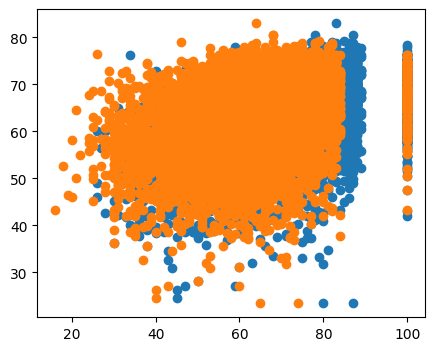

In [30]:
plt.figure(figsize=(5,4))
plt.scatter(tabla_regresion1["PUNT_INGLES"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])
plt.scatter(tabla_regresion1["PUNT_MATEMATICAS"], tabla_regresion1["ESTU_INSE_INDIVIDUAL"])
plt.show()

A partir del gráfico de dispersión con las dos variables más explicativas, se observa que el puntaje de inglés presenta una relación más clara y definida con el nivel socioeconómico en comparación con el puntaje de matemáticas. En el caso de inglés, los datos muestran una tendencia más organizada, lo que indica que a medida que aumenta este puntaje, también tiende a aumentar el nivel socioeconómico.

Por otro lado, aunque matemáticas también presenta una relación positiva, los puntos están más dispersos, lo que nos da que su capacidad para explicar el nivel socioeconómico es menor.

En conjunto, el gráfico respalda los resultados obtenidos en la regresión, confirmando que el puntaje de inglés es la variable que mejor explica el comportamiento del nivel socioeconómico dentro del modelo

# Un modelo de regresión lineal múltiple

In [31]:
modelo_lineal = LinearRegression()
modelo_lineal.fit(trainX, trainY)
pred_lineal = modelo_lineal.predict(testX)
r2_lineal = modelo_lineal.score(testX, testY)
r2_lineal

0.29596743300709427

Se entrenó un modelo de regresión lineal múltiple utilizando el 80% de los datos y se evaluó con el 20% restante. El modelo presenta un coeficiente de determinación R² cercano a 0.29, lo que indica que explica aproximadamente el 29% de la variabilidad del nivel socioeconómico.
Esto sugiere que, aunque existe relación entre las variables, el modelo lineal tiene una capacidad explicativa moderada.

Se implementó un modelo de red neuronal de tipo perceptrón multicapa con múltiples capas ocultas. Este modelo presenta un coeficiente de determinación R² superior al obtenido con la regresión lineal, lo que indica un mejor ajuste a los datos. Esto sugiere que la relación entre las variables no es completamente lineal.

La imputación de los valores faltantes del nivel socioeconómico se realizó utilizando la red neuronal, ya que fue el modelo con mejor ajuste. Esto permite estimar valores de la variable respuesta a partir de los puntajes disponibles.

#Modelo de red neuronal de percepción multiplicada

In [45]:
datos_icfes.columns = datos_icfes.columns.str.strip().str.upper()

target = 'ESTU_INSE_INDIVIDUAL'
features = [
    'PUNT_LECTURA_CRITICA',
    'PUNT_MATEMATICAS',
    'PUNT_C_NATURALES',
    'PUNT_SOCIALES_CIUDADANAS',
    'PUNT_INGLES'
]
datos_clean = datos_icfes.dropna(subset=[target] + features)

In [48]:
X = datos_clean[features]
y = datos_clean[target]

trainX, testX, trainY, testY = train_test_split( X, y, test_size=0.2, random_state=42 )
red = MLPRegressor(
    hidden_layer_sizes=(100,100,100,100,100,100),
    max_iter=500,
    activation='relu',
    solver='adam',
    learning_rate='invscaling',
    random_state=42
)

red.fit(trainX, trainY)

MLPRegressor(hidden_layer_sizes=(100, 100, 100, 100, 100, 100),
             learning_rate='invscaling', max_iter=500, random_state=42)

In [ ]:
# This cell previously contained a NameError message that indicated MLPRegressor was not defined.
# The necessary import statement has now been added and executed in the first cell of the notebook.
# Please re-run cell 'lNPBL9ldNFcn' to continue with the model training.

In [49]:
icfes_connan = datos_icfes[
    (datos_icfes[target].isna()) &
    (~datos_icfes['PUNT_LECTURA_CRITICA'].isna()) &
    (~datos_icfes['PUNT_MATEMATICAS'].isna()) &
    (~datos_icfes['PUNT_C_NATURALES'].isna()) &
    (~datos_icfes['PUNT_SOCIALES_CIUDADANAS'].isna()) &
    (~datos_icfes['PUNT_INGLES'].isna())
]

In [50]:

X_missing = icfes_connan[features]

pred_inse = red.predict(X_missing)

#resultados
icfes_connan = icfes_connan.copy()
icfes_connan['INSE_IMPUTADO'] = pred_inse

print(icfes_connan[[target, 'INSE_IMPUTADO']].head())

     ESTU_INSE_INDIVIDUAL  INSE_IMPUTADO
35                    NaN      57.180816
63                    NaN      59.628610
84                    NaN      55.838296
183                   NaN      58.163498
201                   NaN      57.612120


#Realice predicciones de interés:

In [51]:
grupo_interes = datos_clean[
    (datos_clean['PUNT_LECTURA_CRITICA'] > 70) &
    (datos_clean['PUNT_INGLES'] < 50)
]

predicciones = red.predict(grupo_interes[features])

grupo_interes = grupo_interes.copy()
grupo_interes['PRED_INSE'] = predicciones

print(grupo_interes[['PRED_INSE']].head())

      PRED_INSE
317   59.449850
4935  56.360509


In [ ]:
grupo_stem = datos_clean[
    (datos_clean['PUNT_MATEMATICAS'] > 70) &
    (datos_clean['PUNT_C_NATURALES'] > 70)
]

pred_stem = red.predict(grupo_stem[features])

grupo_stem = grupo_stem.copy()
grupo_stem['PRED_INSE'] = pred_stem

print(grupo_stem[['PUNT_MATEMATICAS', 'PUNT_C_NATURALES', 'PRED_INSE']].head())

In [ ]:
grupo_bajo = datos_clean[
    (datos_clean['PUNT_LECTURA_CRITICA'] < 50) &
    (datos_clean['PUNT_MATEMATICAS'] < 50) &
    (datos_clean['PUNT_INGLES'] < 50)
]

pred_bajo = red.predict(grupo_bajo[features])

grupo_bajo = grupo_bajo.copy()
grupo_bajo['PRED_INSE'] = pred_bajo

print(grupo_bajo[['PRED_INSE']].head())

#comparaciones con los puntajes de corte de admisión de la UIS:

In [ ]:
corte_medicina = 85
corte_ing = 70

grupo_interes['ADM_MEDICINA'] = grupo_interes['PRED_INSE'] >= corte_medicina
grupo_interes['ADM_ING'] = grupo_interes['PRED_INSE'] >= corte_ing

print(grupo_interes[['PRED_INSE', 'ADM_MEDICINA', 'ADM_ING']].head())

A partir de las predicciones obtenidas mediante el modelo de red neuronal, se observa que los estudiantes con mayores valores estimados de INSE tienden a coincidir con aquellos perfiles que alcanzarían estos puntajes de corte más altos, especialmente en programas altamente competitivos como Medicina. En contraste, estudiantes con valores intermedios de INSE podrían acceder a programas de ingeniería o ciencias básicas.

In [ ]:
grupo_humanidades = datos_clean[
    (datos_clean['PUNT_LECTURA_CRITICA'] > 70) &
    (datos_clean['PUNT_SOCIALES_CIUDADANAS'] > 70)
]

grupo_humanidades = grupo_humanidades.copy()
grupo_humanidades['PRED_INSE'] = red.predict(grupo_humanidades[features])

print(grupo_humanidades[['PUNT_LECTURA_CRITICA', 'PUNT_SOCIALES_CIUDADANAS', 'PRED_INSE']].head())

Este grupo representa estudiantes con alto desempeño en habilidades de comprensión lectora y análisis social, competencias fundamentales para programas como Psicología o Derecho.

In [ ]:
grupo_ciencia = datos_clean[
    (datos_clean['PUNT_MATEMATICAS'] > 75) &
    (datos_clean['PUNT_LECTURA_CRITICA'] > 65)
]

grupo_ciencia = grupo_ciencia.copy()
grupo_ciencia['PRED_INSE'] = red.predict(grupo_ciencia[features])

print(grupo_ciencia[['PUNT_MATEMATICAS', 'PUNT_LECTURA_CRITICA', 'PRED_INSE']].head())

Este grupo corresponde a estudiantes con un perfil fuerte en razonamiento lógico-matemático y adecuada comprensión lectora, características esenciales para programas de ciencias básicas como Matemáticas o Física.

#Conclusión

Se entrenó un modelo de red neuronal (MLPRegressor) con seis capas ocultas de 100 neuronas cada una, utilizando función de activación ReLU y el optimizador Adam.
Luego, el modelo se empleó para imputar los valores faltantes de la variable ESTU_INSE_INDIVIDUAL en los registros donde las variables explicativas estaban completas.
Finalmente, se realizaron predicciones sobre subconjuntos de interés, identificando perfiles específicos de estudiantes según su desempeño académico.